In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

### Proxy profit analysis of Top Ten car brands 

In [75]:
df_cars=pd.read_csv("cleaned_data.csv")

In [76]:
df_cars=df_cars[df_cars["vehicle_age"]<25]

In [77]:
pd.options.display.float_format = "{:.3f}".format

In [78]:
top_fifteen=df_cars["make"].value_counts()[0:15]

In [79]:
t_fifteen_make=pd.DataFrame(top_fifteen).reset_index()["make"]

In [81]:
df_cars["proxy_profit"]=df_cars["sellingprice"]-df_cars["mmr"]

In [82]:
df_cars["proxy_profit_percent"]=(df_cars["proxy_profit"]/df_cars["mmr"])*100

In [83]:
df_cars["proxy_profit_percent"]

0         -5.956
1          0.909
2          1.515
3         -5.797
4        -17.647
           ...  
558593    -6.516
558594     1.987
558595    14.094
558596   -26.490
558597    -9.797
Name: proxy_profit_percent, Length: 558481, dtype: float64

In [84]:
df_mixed=df_cars.groupby(["state", "make"],as_index=False)[["mmr","proxy_profit", "proxy_profit_percent","vehicle_age","odometer"]].mean()

In [85]:
plot_df_profits = (
    df_cars
    .groupby(["make", "vehicle_age"], as_index=False)["proxy_profit_percent"]
    .mean()
)

In [86]:
plot_df_profits_filtered = plot_df_profits[plot_df_profits["make"].isin(t_fifteen_make)]

### Outlier removal

In [87]:

filreted_grp=[]
grp=plot_df_profits_filtered.groupby('make')
for mak,df in grp:
    std=df['proxy_profit_percent'].std()
    avg=df['proxy_profit_percent'].mean()
    df=df[(df['proxy_profit_percent']>avg-3*std)&(df['proxy_profit_percent']<avg+3*std)]
    df["make"]=mak
    filreted_grp.append(df)

plot_df_profits_filtered=pd.concat(filreted_grp, ignore_index=True)

C:\Users\ojasv\AppData\Local\Temp\ipykernel_28704\1358797101.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["make"]=mak


In [88]:
plot_df_profits_filtered.shape

(21835, 3)

### Plots

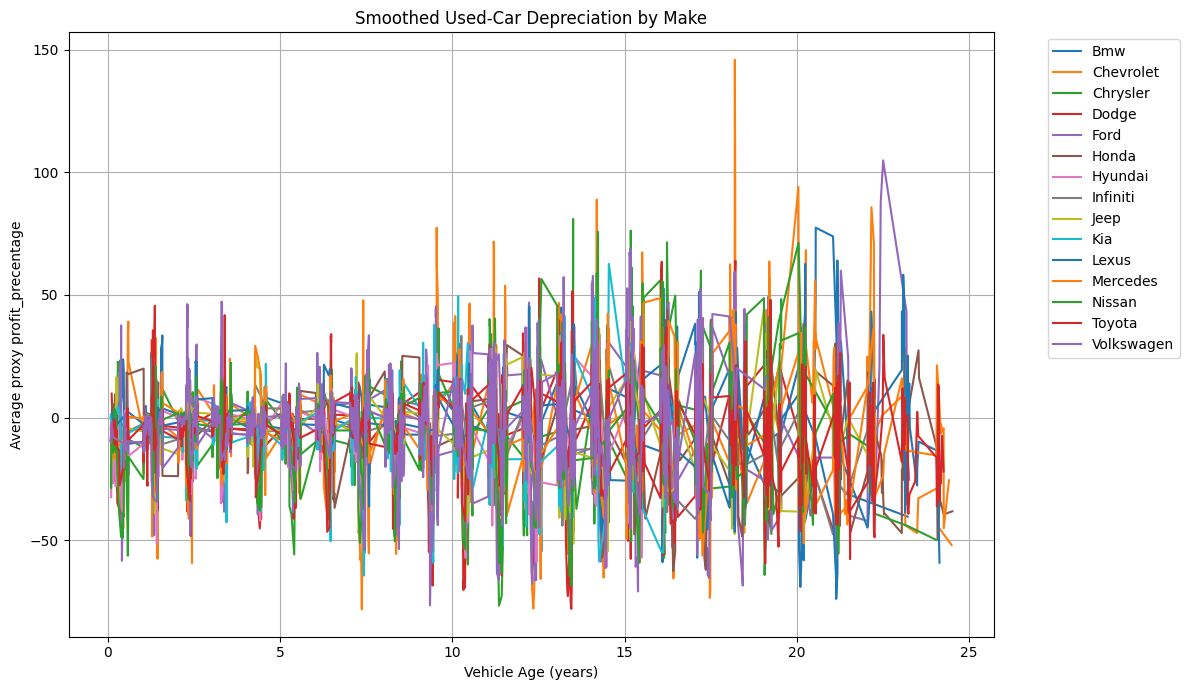

In [92]:
window = 3

plt.figure(figsize=(12, 7))

for make, grp in plot_df_profits_filtered.groupby("make"):
    grp = grp.sort_values("vehicle_age")
    smoothed = grp["proxy_profit_percent"].rolling(window=window, center=True).mean()

    plt.plot(grp["vehicle_age"], smoothed, label=make)

plt.xlabel("Vehicle Age (years)")
plt.ylabel("Average proxy profit_precentage")
plt.title("Smoothed Used-Car Depreciation by Make")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

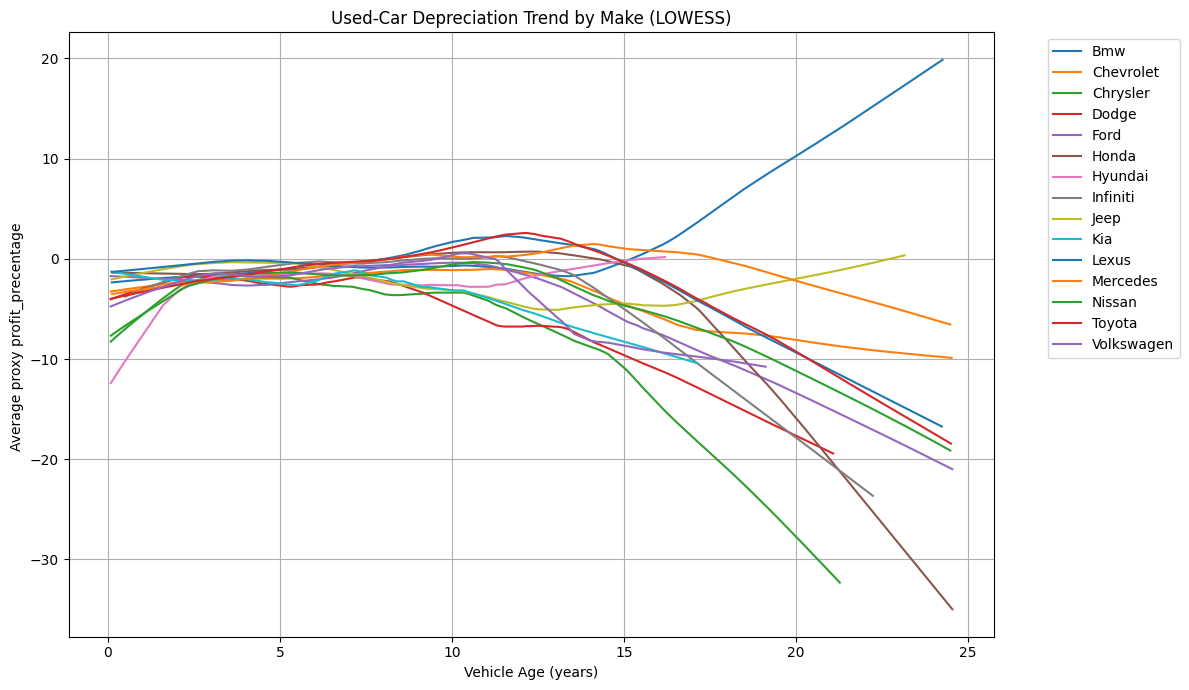

In [91]:
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.figure(figsize=(12, 7))

for make, grp in plot_df_profits_filtered.groupby("make"):
    grp = grp.sort_values("vehicle_age")
    smoothed = lowess(
        grp["proxy_profit_percent"],
        grp["vehicle_age"],
        frac=0.3  
    )

    plt.plot(smoothed[:, 0], smoothed[:, 1], label=make)

plt.xlabel("Vehicle Age (years)")
plt.ylabel("Average proxy profit_precentage ")
plt.title("Used-Car Depreciation Trend by Make (LOWESS)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

## Insights
### Newer used vehicles (0–7 years) trade very close to market benchmarks, indicating a highly efficient and competitive pricing environment.
### Pricing volatility increases significantly for older vehicles, suggesting higher risk but also greater opportunity for skilled pricing strategies.
### Brand-specific pricing behavior emerges at higher vehicle ages, reinforcing the need for differentiated pricing models by manufacturer.
### MMR reliability decreases for older vehicles, highlighting the importance of manual overrides or adjusted valuation models in aged inventory.
### BMW shows high Value retention as compared to other makes. 